# Ethylene case study

This notebook demonstrates environmental and economic optimization of three
ethylene routes with optimex. All results remain provisional while proxy assumptions
are present.


## 1. Data and scenario

The study covers Europe from 2025 to 2050 and uses the
`REMIND-EU_SSP2-NDC` premise databases. Annual ethylene demand is constant at
`1e9 kg/a`. The routes are steam cracking, methanol-to-olefins supplied by DAC,
PEM electrolysis and CO2 hydrogenation, and an aggregated eCO2R process that
includes product separation.

Case-study-specific background activities are stored in four small interface
databases. They link to the corresponding premise activities for each support
year while leaving the premise databases unchanged.

The use phase, ethylene product end-of-life and plant end-of-life are excluded.
Separated eCO2R co-products and their further treatment are also excluded.
Consequently, neither additional purification burdens nor potential product
credits are represented.

In [1]:
from datetime import datetime
from pathlib import Path

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from bw_temporalis import TemporalDistribution
from IPython.display import display

from optimex.utils import (
    infer_construction_td_from_limits,
    infer_operation_td_from_limits,
)

PROJECT = "optimex_remind"
BIOSPHERE_DB = "ecoinvent-3.12-biosphere"
FOREGROUND_DB = "ethylene_case_study_foreground"
PREMISE_DBS = {
    2020: "ei312_REMIND-EU_SSP2_NDC_2020",
    2030: "ei312_REMIND-EU_SSP2_NDC_2030",
    2040: "ei312_REMIND-EU_SSP2_NDC_2040",
    2050: "ei312_REMIND-EU_SSP2_NDC_2050",
}
CASE_STUDY_BG_DBS = {
    year: f"ethylene_case_study_background_{year}"
    for year in PREMISE_DBS
}

bd.projects.set_current(PROJECT)
required_databases = {BIOSPHERE_DB, *PREMISE_DBS.values()}
missing_databases = required_databases - set(bd.databases)
if missing_databases:
    raise ValueError(f"Missing databases: {sorted(missing_databases)}")

## 2. Model assumptions

The table collects the assumptions that control plant lifetimes, reference
capacities, installation scaling, existing capacity and discounting. For the
route-specific CAPEX wrappers, the outer exchange represents one physical plant
per reference capacity and lifetime. The original environmental installation
coefficient is preserved by inverse scaling inside the wrapper. Final runs require
the corrected `var_installation` semantics to pass a multi-year static-LCA
equivalence test. The brownfield capacities must also be revalidated against that
corrected variable definition.


In [2]:
assumptions = pd.DataFrame(
    [
        ("lifetime.steam_cracking", 25, "year", "RESEARCHED", "Tiggeloven (2026), Table C.1, conventional cracker", False),
        ("lifetime.dac", 20, "year", "RESEARCHED", "Deutz and Bardow (2021), https://doi.org/10.1038/s41560-020-00771-9", False),
        ("lifetime.pem", 25, "year", "PROXY", "Tiggeloven (2026), Table C.1, AEC plant; separate 9-year stack replacement not modeled", True),
        ("lifetime.co2_hydrogenation", 25, "year", "RESEARCHED", "Tiggeloven (2026), Table C.1, direct methanol synthesis from CO2", False),
        ("lifetime.mto", 25, "year", "RESEARCHED", "Tiggeloven (2026), Table C.1, methanol-to-olefins", False),
        ("lifetime.eco2r", 25, "year", "PROXY", "Tiggeloven (2026), Table C.1, CO2 electrolysis and air-separation-unit proxies", True),
        ("capacity.steam_cracking", 1e9, "kg ethylene/a", "RESEARCHED", "Tiggeloven (2026), Chapter 2 reference cracker", False),
        ("capacity.pem", 156414.347247488, "kg H2/a", "PROXY", "1 MWe at 8760 h/a divided by 56.00509259 kWh/kg H2", True),
        ("capacity.co2_hydrogenation", 6.134969325153374e9, "kg methanol/a", "RESEARCHED", "Sized to the methanol demand of the 1 Mt ethylene/a MTO reference using Tiggeloven Table C.2", False),
        ("capacity.mto", 1e9, "kg ethylene/a", "RESEARCHED", "Common case-study reference output using Tiggeloven Table C.2", False),
        ("capacity.eco2r", 1e9, "kg ethylene/a", "PROXY", "Common case-study reference output using Tiggeloven CO2-electrolysis data", True),
        ("allocation.steam_cracking", 0.5222337125129265, "fraction", "PROXY", "PlasticsEurope main-product mass rule with Zimmermann and Walzl yields from Tiggeloven Table A.6", True),
        ("allocation.pem", 1.0, "fraction", "MODEL", "No product allocation in the foreground LCI", False),
        ("allocation.co2_hydrogenation", 1.0, "fraction", "MODEL", "No product allocation in the foreground LCI", False),
        ("allocation.mto", 0.4, "fraction", "MODEL", "disco2very mass allocation inherited by costs", False),
        ("allocation.eco2r", 1.0, "fraction", "MODEL", "No product allocation in the foreground LCI", False),
        (
            "installation.steam_factory",
            1.1516356618335166e-10,
            "unit/kg ethylene",
            "INVENTORY",
            "ecoinvent net coefficient preserved through the route-specific wrapper",
            False,
        ),
        (
            "installation.dac_system",
            1.25e-8,
            "unit/kg CO2",
            "INVENTORY",
            "disco2very 4 kt CO2/a DAC inventory coefficient copied unchanged",
            False,
        ),
        (
            "installation.pem_stack",
            1.34989e-6,
            "unit/kg H2",
            "INVENTORY",
            "methanol_and_iron inventory coefficient copied unchanged",
            False,
        ),
        (
            "installation.pem_bop",
            3.37373e-7,
            "unit/kg H2",
            "INVENTORY",
            "methanol_and_iron inventory coefficient copied unchanged",
            False,
        ),
        (
            "installation.co2_hydrogenation_factory",
            3.5842e-12,
            "unit/kg methanol",
            "INVENTORY",
            "disco2very net coefficient preserved through the route-specific wrapper",
            False,
        ),
        (
            "installation.mto_factory",
            3.584e-12,
            "unit/kg ethylene",
            "INVENTORY",
            "disco2very net coefficient preserved through the route-specific wrapper",
            False,
        ),
        (
            "installation.eco2r_factory",
            4e-10,
            "unit installation/kg ethylene",
            "INVENTORY",
            "Corrected with the disco2very inventory creator: chemical factory construction, organics",
            False,
        ),
        (
            "installation.eco2r_copper",
            7.4e-11,
            "kg/kg ethylene",
            "INVENTORY",
            "Internal input of the aggregated eCO2R installation wrapper",
            False,
        ),
        (
            "installation.eco2r_steel",
            3.017679e-6,
            "kg/kg ethylene",
            "INVENTORY",
            "Internal input of the aggregated eCO2R installation wrapper",
            False,
        ),
        ("brownfield.vintage_1", 2005, "year", "PROXY", "methanol_and_iron brownfield pattern", True),
        ("brownfield.vintage_2", 2015, "year", "PROXY", "methanol_and_iron brownfield pattern", True),
        ("brownfield.capacity_per_vintage", 0.5e9, "kg ethylene/a", "PROXY", "Two equal vintages", False),
        ("economics.discount_rate", 0.03, "real fraction/a", "PROXY", "basic_example_econ", True),
    ],
    columns=[
        "parameter", "value", "unit", "status", "basis", "replacement_needed"
    ],
).set_index("parameter")

PROCESS_NAMES = {
    "steam_cracking": "Steam cracking",
    "dac": "Direct air capture",
    "pem": "PEM electrolysis",
    "co2_hydrogenation": "CO2 hydrogenation to methanol",
    "mto": "Methanol-to-olefins",
    "eco2r": "eCO2R ethylene production",
}
LIFETIMES_YEARS = {
    process: int(assumptions.loc[f"lifetime.{process}", "value"])
    for process in PROCESS_NAMES
}
ENVIRONMENTAL_INSTALLATION_AMOUNTS = {
    key.removeprefix("installation."): float(row["value"])
    for key, row in assumptions.loc[
        assumptions.index.str.startswith("installation.")
    ].iterrows()
}
REFERENCE_CAPACITIES_KG_PER_YEAR = {
    process: float(assumptions.loc[f"capacity.{process}", "value"])
    for process in ["steam_cracking", "pem", "co2_hydrogenation", "mto", "eco2r"]
}
CAPEX_ALLOCATION_FACTORS = {
    process: float(assumptions.loc[f"allocation.{process}", "value"])
    for process in ["steam_cracking", "pem", "co2_hydrogenation", "mto", "eco2r"]
}
WRAPPER_INSTALLATION_AMOUNTS = {
    process: 1.0 / (
        REFERENCE_CAPACITIES_KG_PER_YEAR[process] * LIFETIMES_YEARS[process]
    )
    for process in REFERENCE_CAPACITIES_KG_PER_YEAR
}
assert np.isclose(WRAPPER_INSTALLATION_AMOUNTS["steam_cracking"], 4e-11, rtol=1e-12, atol=0.0)
assert np.isclose(WRAPPER_INSTALLATION_AMOUNTS["pem"], 2.55731016392694e-7, rtol=1e-12, atol=0.0)
assert np.isclose(WRAPPER_INSTALLATION_AMOUNTS["co2_hydrogenation"], 6.52e-12, rtol=1e-12, atol=0.0)
assert np.isclose(WRAPPER_INSTALLATION_AMOUNTS["mto"], 4e-11, rtol=1e-12, atol=0.0)
assert np.isclose(WRAPPER_INSTALLATION_AMOUNTS["eco2r"], 4e-11, rtol=1e-12, atol=0.0)

assumptions

,value,unit,status,basis,replacement_needed
parameter,,,,,
lifetime.steam_cracking,2.500000e+01,year,RESEARCHED,"Tiggeloven (2026), Table C.1, conventional cra...",False
lifetime.dac,2.000000e+01,year,RESEARCHED,"Deutz and Bardow (2021), https://doi.org/10.10...",False
lifetime.pem,2.500000e+01,year,PROXY,"Tiggeloven (2026), Table C.1, AEC plant; separ...",True
lifetime.co2_hydrogenation,2.500000e+01,year,RESEARCHED,"Tiggeloven (2026), Table C.1, direct methanol ...",False
lifetime.mto,2.500000e+01,year,RESEARCHED,"Tiggeloven (2026), Table C.1, methanol-to-olefins",False
lifetime.eco2r,2.500000e+01,year,PROXY,"Tiggeloven (2026), Table C.1, CO2 electrolysis...",True
capacity.steam_cracking,1.000000e+09,kg ethylene/a,RESEARCHED,"Tiggeloven (2026), Chapter 2 reference cracker",False
capacity.pem,1.564143e+05,kg H2/a,PROXY,1 MWe at 8760 h/a divided by 56.00509259 kWh/k...,True
capacity.co2_hydrogenation,6.134969e+09,kg methanol/a,RESEARCHED,Sized to the methanol demand of the 1 Mt ethyl...,False


## 3. Case-study background

The four case-study databases form the temporal background family seen by
optimex. Ordinary purchases are represented by transparent one-to-one interface
activities that link to the matching premise activity of the same year.

The databases also contain the seven-component steam-cracking feedstock mix,
route-specific installation wrappers and three DAC-specific activities reproduced
from disco2very. The DAC construction excludes plant end-of-life to retain the
cradle-to-gate system boundary. No activity is written to a premise database.

In [3]:
PEI_NAME = "polyethyleneimine production"
PEI_PRODUCT = "polyethyleneimine"
ADSORBENT_NAME = "adsorbent, amine on alumina"
ADSORBENT_PRODUCT = "adsorbent, amine on alumina"
DAC_4KT_NAME = "direct air capture system construction, solid sorbent, 4 ktCO2/a"
DAC_4KT_PRODUCT = "direct air capture system, solid sorbent, 4 ktCO2/a"
FEEDSTOCK_MIX_NAME = "steam cracking feedstock mix"
STEAM_INSTALLATION_NAME = "steam cracker installation"
CO2_HYDROGENATION_INSTALLATION_NAME = "CO2 hydrogenation installation"
MTO_INSTALLATION_NAME = "methanol-to-olefins installation"
ECO2R_INSTALLATION_NAME = "eCO2R system installation"
PEM_INSTALLATION_NAME = "PEM electrolyzer system installation, 1 MWe"

STEAM_FEEDSTOCK_TOTAL = 1.21675954200327
STEAM_FEEDSTOCK_INPUTS = [
    ("market for butane", "butane", "RoW", "kilogram", 0.19711504876613617),
    ("market for ethane", "ethane", "RoW", "kilogram", 0.05475417897105217),
    ("market for naphtha", "naphtha", "RER", "kilogram", 0.7787261009216309),
    ("market for natural gas liquids", "natural gas liquids", "RoW", "kilogram", 0.02676870860159397),
    ("market for propane", "propane", "RoW", "kilogram", 0.09247373044490814),
    ("market for refinery gas", "refinery gas", "GLO", "kilogram", 0.018251389265060425),
    ("market for diesel", "diesel", "DEU", "kilogram", 0.04867038503289223),
]
assert np.isclose(
    sum(item[4] for item in STEAM_FEEDSTOCK_INPUTS),
    STEAM_FEEDSTOCK_TOTAL,
)

INTERFACE_SPECS = [
    ("cooling_minus_25", "cooling energy production, at -25 °C, propylene compression refrigeration system 1 MW", "cooling energy, at -25 °C", "GLO", "megajoule"),
    ("pem_bop", "electrolyzer production, 1MWe, PEM, Balance of Plant", "electrolyzer, 1MWe, PEM, Balance of Plant", "RER", "unit"),
    ("pem_stack", "electrolyzer production, 1MWe, PEM, Stack", "electrolyzer, 1MWe, PEM, Stack", "RER", "unit"),
    ("heat_pump", "heat production, at heat pump 30kW, allocation exergy", "heat, central or small-scale, other than natural gas", "Europe without Switzerland", "megajoule"),
    ("compressed_air", "market for compressed air, 700 kPa gauge", "compressed air, 700 kPa gauge", "RER", "cubic meter"),
    ("cooling", "market for cooling energy", "cooling energy", "GLO", "megajoule"),
    ("cooling_minus_100", "market for cooling energy, at -100 °C", "cooling energy, at -100 °C", "GLO", "megajoule"),
    ("cooling_minus_15", "market for cooling energy, at -15 °C", "cooling energy, at -15 °C", "GLO", "megajoule"),
    ("cooling_minus_45", "market for cooling energy, at -45 °C", "cooling energy, at -45 °C", "GLO", "megajoule"),
    ("cooling_minus_55", "market for cooling energy, at -55 °C", "cooling energy, at -55 °C", "GLO", "megajoule"),
    ("electricity_mv", "market for electricity, medium voltage", "electricity, medium voltage", "DE", "kilowatt hour"),
    ("hazardous_waste_incineration", "market for hazardous waste, for incineration", "hazardous waste, for incineration", "CH", "kilogram"),
    ("hazardous_waste_underground", "market for hazardous waste, for underground deposit", "hazardous waste, for underground deposit", "RER", "kilogram"),
    ("industrial_heat", "market for heat, district or industrial, natural gas", "heat, district or industrial, natural gas", "Europe without Switzerland", "megajoule"),
    ("inert_waste", "market for inert waste, for final disposal", "inert waste, for final disposal", "CH", "kilogram"),
    ("background_methanol", "market for methanol", "methanol", "RER w/o RU", "kilogram"),
    ("nitrogen_liquid", "market for nitrogen, liquid", "nitrogen, liquid", "RER", "kilogram"),
    ("sodium_hydroxide", "market for sodium hydroxide, without water, in 50% solution state", "sodium hydroxide, without water, in 50% solution state", "RER", "kilogram"),
    ("wastewater_average", "market for wastewater, average", "wastewater, average", "CH", "cubic meter"),
    ("wastewater_unpolluted", "market for wastewater, unpolluted", "wastewater, unpolluted", "RoW", "cubic meter"),
    ("water_deionised_ch", "market for water, deionised", "water, deionised", "CH", "kilogram"),
    ("water_deionised_europe", "market for water, deionised", "water, deionised", "Europe without Switzerland", "kilogram"),
    ("electricity_mv_deu", "market group for electricity, medium voltage", "electricity, medium voltage", "DEU", "kilowatt hour"),
    ("spent_adsorbent_treatment", "treatment of spent anion exchange resin from potable water production, municipal incineration", "spent anion exchange resin from potable water production", "GLO", "kilogram"),
]


def premise_node(database_name, *, name, product, location, unit):
    return bd.get_node(
        database=database_name,
        name=name,
        product=product,
        location=location,
        unit=unit,
    )


def create_case_activity(database, *, code, name, product, location, unit, comment):
    activity = database.new_node(
        code=code,
        name=name,
        product=product,
        location=location,
        unit=unit,
        type=bd.labels.process_node_default,
    )
    activity["reference product"] = product
    activity["comment"] = comment
    activity.save()
    activity.new_edge(
        input=activity,
        amount=1.0,
        type=bd.labels.production_edge_default,
    ).save()
    return activity


def lookup_premise(database_name, name, location, product=None):
    lookup = {"database": database_name, "name": name, "location": location}
    if product is not None:
        lookup["product"] = product
    return bd.get_node(**lookup)


for year, premise_database_name in PREMISE_DBS.items():
    case_database_name = CASE_STUDY_BG_DBS[year]
    if case_database_name in bd.databases:
        del bd.databases[case_database_name]
    case_database = bd.Database(case_database_name)
    case_database.register()
    case_database.metadata["representative_time"] = datetime(year, 1, 1).isoformat()

    interfaces = {}
    for code, name, product, location, unit in INTERFACE_SPECS:
        source = premise_node(
            premise_database_name,
            name=name,
            product=product,
            location=location,
            unit=unit,
        )
        interface = create_case_activity(
            case_database,
            code=f"interface_{code}",
            name=name,
            product=product,
            location=location,
            unit=unit,
            comment=f"Case-study interface to {source.key} for support year {year}.",
        )
        interfaces[code] = interface
        interface.new_edge(
            input=source,
            amount=1.0,
            type=bd.labels.consumption_edge_default,
        ).save()

    pem_wrapper_amount = WRAPPER_INSTALLATION_AMOUNTS["pem"]
    pem_system_installation = create_case_activity(
        case_database,
        code="pem_electrolyzer_system_installation_1mwe",
        name=PEM_INSTALLATION_NAME,
        product=PEM_INSTALLATION_NAME,
        location="RER",
        unit="unit",
        comment=(
            "One 1 MWe PEM system with 25-year model lifetime and "
            "156414.347 kg H2/a full-load reference output. Internal Stack "
            "and Balance-of-Plant amounts preserve their original LCI coefficients."
        ),
    )
    for environmental_key, interface_key in [
        ("pem_stack", "pem_stack"),
        ("pem_bop", "pem_bop"),
    ]:
        environmental_amount = ENVIRONMENTAL_INSTALLATION_AMOUNTS[environmental_key]
        internal_amount = environmental_amount / pem_wrapper_amount
        pem_system_installation.new_edge(
            input=interfaces[interface_key],
            amount=internal_amount,
            type=bd.labels.consumption_edge_default,
        ).save()
        assert np.isclose(
            pem_wrapper_amount * internal_amount,
            environmental_amount,
            rtol=1e-12,
            atol=0.0,
        )

    feedstock_mix = create_case_activity(
        case_database,
        code="steam_cracking_feedstock_mix",
        name=FEEDSTOCK_MIX_NAME,
        product=FEEDSTOCK_MIX_NAME,
        location="RER w/o RU",
        unit="kilogram",
        comment=(
            "One kilogram of the ecoinvent steam-cracker feedstock slate. "
            "Diesel proxies atmospheric gas oil; the seven mass shares sum to one."
        ),
    )
    for name, product, location, unit, source_amount in STEAM_FEEDSTOCK_INPUTS:
        feedstock_mix.new_edge(
            input=premise_node(
                premise_database_name,
                name=name,
                product=product,
                location=location,
                unit=unit,
            ),
            amount=source_amount / STEAM_FEEDSTOCK_TOTAL,
            type=bd.labels.consumption_edge_default,
        ).save()

    chemical_factory_organics_source = premise_node(
        premise_database_name,
        name="chemical factory construction, organics",
        product="chemical factory, organics",
        location="RER",
        unit="unit",
    )
    for code, name, location, process, environmental_key in [
        ("steam_cracker_installation", STEAM_INSTALLATION_NAME, "RER w/o RU", "steam_cracking", "steam_factory"),
        ("co2_hydrogenation_installation", CO2_HYDROGENATION_INSTALLATION_NAME, "RER", "co2_hydrogenation", "co2_hydrogenation_factory"),
        ("mto_installation", MTO_INSTALLATION_NAME, "RER", "mto", "mto_factory"),
    ]:
        wrapper_amount = WRAPPER_INSTALLATION_AMOUNTS[process]
        environmental_amount = ENVIRONMENTAL_INSTALLATION_AMOUNTS[environmental_key]
        internal_factory_amount = environmental_amount / wrapper_amount
        installation = create_case_activity(
            case_database,
            code=code,
            name=name,
            product=name,
            location=location,
            unit="unit",
            comment=(
                f"One {process} reference installation with "
                f"{REFERENCE_CAPACITIES_KG_PER_YEAR[process]:.10g} kg/a capacity. "
                "Its internal factory amount preserves the original net LCI coefficient."
            ),
        )
        installation.new_edge(
            input=chemical_factory_organics_source,
            amount=internal_factory_amount,
            type=bd.labels.consumption_edge_default,
        ).save()
        assert np.isclose(
            wrapper_amount * internal_factory_amount,
            environmental_amount,
            rtol=1e-12,
            atol=0.0,
        )

    eco2r_wrapper_amount = WRAPPER_INSTALLATION_AMOUNTS["eco2r"]
    eco2r_installation = create_case_activity(
        case_database,
        code="eco2r_system_installation",
        name=ECO2R_INSTALLATION_NAME,
        product=ECO2R_INSTALLATION_NAME,
        location="DE",
        unit="unit",
        comment=(
            "One aggregated eCO2R reactor and separation installation with "
            "1e9 kg ethylene/a reference capacity. Internal factory, copper "
            "and steel amounts preserve the original net LCI coefficients."
        ),
    )
    eco2r_installation.new_edge(
        input=chemical_factory_organics_source,
        amount=(
            ENVIRONMENTAL_INSTALLATION_AMOUNTS["eco2r_factory"]
            / eco2r_wrapper_amount
        ),
        type=bd.labels.consumption_edge_default,
    ).save()
    eco2r_installation.new_edge(
        input=premise_node(
            premise_database_name,
            name="market for copper, cathode",
            product="copper, cathode",
            location="GLO",
            unit="kilogram",
        ),
        amount=(
            ENVIRONMENTAL_INSTALLATION_AMOUNTS["eco2r_copper"]
            / eco2r_wrapper_amount
        ),
        type=bd.labels.consumption_edge_default,
    ).save()
    eco2r_installation.new_edge(
        input=premise_node(
            premise_database_name,
            name="market for steel, low-alloyed",
            product="steel, low-alloyed",
            location="GLO",
            unit="kilogram",
        ),
        amount=(
            ENVIRONMENTAL_INSTALLATION_AMOUNTS["eco2r_steel"]
            / eco2r_wrapper_amount
        ),
        type=bd.labels.consumption_edge_default,
    ).save()
    for environmental_key in ["eco2r_factory", "eco2r_copper", "eco2r_steel"]:
        environmental_amount = ENVIRONMENTAL_INSTALLATION_AMOUNTS[environmental_key]
        assert np.isclose(
            eco2r_wrapper_amount * (environmental_amount / eco2r_wrapper_amount),
            environmental_amount,
            rtol=1e-12,
            atol=0.0,
        )

    pei = create_case_activity(
        case_database,
        code="ethylene_case_study_polyethyleneimine",
        name=PEI_NAME,
        product=PEI_PRODUCT,
        location="DE",
        unit="kilogram",
        comment=(
            "Case-study reproduction of the disco2very polyethyleneimine "
            "inventory based on Deutz and Bardow (2021), "
            "https://doi.org/10.1038/s41560-020-00771-9."
        ),
    )
    pei_inputs = [
        ("market for monoethanolamine", "GLO", None, 1.42),
        ("sodium sulfate production, from natural sources", "RER", None, -0.86),
        ("market for sodium hydroxide, without water, in 50% solution state", "RER", None, 3.72),
        ("market for hydrochloric acid, without water, in 30% solution state", "RER", None, 0.170666667),
        ("market for ethanol, without water, in 99.7% solution state, from ethylene", "RER", None, 2.84),
        ("ethanol production, ethylene hydration", "RER", "diethyl ether, without water, in 99.95% solution state", 33.94),
        ("water production, deionised", "Europe without Switzerland", None, 11.99),
        ("market for electricity, medium voltage", "DE", None, 0.42),
        ("heat production, natural gas, at industrial furnace low-NOx >100kW", "Europe without Switzerland", None, 2.35),
        ("market for spent solvent mixture", "Europe without Switzerland", None, -0.37),
    ]
    for name, location, product, amount in pei_inputs:
        pei.new_edge(
            input=lookup_premise(
                premise_database_name,
                name=name,
                location=location,
                product=product,
            ),
            amount=amount,
            type=bd.labels.consumption_edge_default,
        ).save()

    adsorbent = create_case_activity(
        case_database,
        code="ethylene_case_study_adsorbent_amine_on_alumina",
        name=ADSORBENT_NAME,
        product=ADSORBENT_PRODUCT,
        location="DE",
        unit="kilogram",
        comment=(
            "Case-study reproduction of the disco2very amine-on-alumina "
            "adsorbent based on Deutz and Bardow (2021) and Leonzio et al. "
            "(2022), https://doi.org/10.1016/j.spc.2022.04.004."
        ),
    )
    adsorbent.new_edge(
        input=pei,
        amount=0.557735849,
        type=bd.labels.consumption_edge_default,
    ).save()
    adsorbent.new_edge(
        input=lookup_premise(
            premise_database_name,
            name="market for aluminium oxide, metallurgical",
            location="IAI Area, Western and Central Europe",
        ),
        amount=0.442264151,
        type=bd.labels.consumption_edge_default,
    ).save()

    dac_system_4kt = create_case_activity(
        case_database,
        code="ethylene_case_study_dac_solid_sorbent_4kt_construction",
        name=DAC_4KT_NAME,
        product=DAC_4KT_PRODUCT,
        location="RER",
        unit="unit",
        comment=(
            "Construction of one solid-sorbent TVSA direct-air-capture system "
            "with 4 kt CO2/a nominal capacity, reproduced from disco2very on "
            "the basis of Deutz and Bardow (2021). Plant end-of-life is excluded."
        ),
    )
    dac_materials = [
        ("market for concrete, 30MPa", "CH", None, 1501),
        ("market for reinforcing steel", "GLO", None, 217590),
        ("market for stone wool", "GLO", None, 2600),
        ("market for steel, chromium steel 18/8", "GLO", None, 47145),
        ("market for polyurethane, rigid foam", "RER", None, 2600),
        ("market for copper, anode", "GLO", None, 2200),
        ("market for aluminium, primary, ingot", "IAI Area, Western and Central Europe", None, 16000),
        ("market for alkyd paint, white, without solvent, in 60% solution state", "RER", None, 1600),
        ("market for synthetic rubber", "GLO", None, 6300),
        ("sheet rolling, aluminium", "RER", None, 16000),
        ("metal working, average for copper product manufacturing", "RER", "metal working, average for copper product manufacturing", 1600),
        ("sheet rolling, copper", "RER", None, 600),
    ]
    for name, location, product, amount in dac_materials:
        dac_system_4kt.new_edge(
            input=lookup_premise(
                premise_database_name,
                name=name,
                location=location,
                product=product,
            ),
            amount=amount,
            type=bd.labels.consumption_edge_default,
        ).save()
    dac_system_4kt.new_edge(
        input=bd.Database(BIOSPHERE_DB).get(
            code="fe9c3a98-a6d2-452d-a9a4-a13e64f1b95b"
        ),
        amount=1045,
        type=bd.labels.biosphere_edge_default,
    ).save()

    case_database.process()

The names, products, locations and units of the 2020 interface nodes provide
the identities used by optimex to resolve the corresponding activities in later
support years. The original 2020 premise steam-cracking activity is read only to
retain its documented direct biosphere exchanges and verify its input amounts.

In [4]:
REFERENCE_DB = CASE_STUDY_BG_DBS[2020]
SOURCE_STEAM_DB = PREMISE_DBS[2020]


def case_node(*, name, product, location, unit):
    return bd.get_node(
        database=REFERENCE_DB,
        name=name,
        product=product,
        location=location,
        unit=unit,
    )


steam_cracking_inventory = bd.get_node(
    database=SOURCE_STEAM_DB,
    name="unsaturated hydrocarbons production, steam cracking operation, average",
    product="ethylene",
    location="RER w/o RU",
    unit="kilogram",
)
electricity_mv = case_node(
    name="market for electricity, medium voltage",
    product="electricity, medium voltage",
    location="DE",
    unit="kilowatt hour",
)
heat_pump = case_node(
    name="heat production, at heat pump 30kW, allocation exergy",
    product="heat, central or small-scale, other than natural gas",
    location="Europe without Switzerland",
    unit="megajoule",
)
water_deionized = case_node(
    name="market for water, deionised",
    product="water, deionised",
    location="Europe without Switzerland",
    unit="kilogram",
)
wastewater = case_node(
    name="market for wastewater, unpolluted",
    product="wastewater, unpolluted",
    location="RoW",
    unit="cubic meter",
)
cooling = case_node(
    name="market for cooling energy",
    product="cooling energy",
    location="GLO",
    unit="megajoule",
)
cooling_minus_15 = case_node(
    name="market for cooling energy, at -15 °C",
    product="cooling energy, at -15 °C",
    location="GLO",
    unit="megajoule",
)
cooling_minus_25 = case_node(
    name="cooling energy production, at -25 °C, propylene compression refrigeration system 1 MW",
    product="cooling energy, at -25 °C",
    location="GLO",
    unit="megajoule",
)
cooling_minus_45 = case_node(
    name="market for cooling energy, at -45 °C",
    product="cooling energy, at -45 °C",
    location="GLO",
    unit="megajoule",
)
cooling_minus_55 = case_node(
    name="market for cooling energy, at -55 °C",
    product="cooling energy, at -55 °C",
    location="GLO",
    unit="megajoule",
)
cooling_minus_100 = case_node(
    name="market for cooling energy, at -100 °C",
    product="cooling energy, at -100 °C",
    location="GLO",
    unit="megajoule",
)
industrial_heat = case_node(
    name="market for heat, district or industrial, natural gas",
    product="heat, district or industrial, natural gas",
    location="Europe without Switzerland",
    unit="megajoule",
)
adsorbent_amine_alumina = case_node(
    name=ADSORBENT_NAME,
    product=ADSORBENT_PRODUCT,
    location="DE",
    unit="kilogram",
)
spent_adsorbent_treatment = case_node(
    name="treatment of spent anion exchange resin from potable water production, municipal incineration",
    product="spent anion exchange resin from potable water production",
    location="GLO",
    unit="kilogram",
)
steam_feedstock_mix = case_node(
    name=FEEDSTOCK_MIX_NAME,
    product=FEEDSTOCK_MIX_NAME,
    location="RER w/o RU",
    unit="kilogram",
)
steam_installation = case_node(
    name=STEAM_INSTALLATION_NAME,
    product=STEAM_INSTALLATION_NAME,
    location="RER w/o RU",
    unit="unit",
)
co2_hydrogenation_installation = case_node(
    name=CO2_HYDROGENATION_INSTALLATION_NAME,
    product=CO2_HYDROGENATION_INSTALLATION_NAME,
    location="RER",
    unit="unit",
)
mto_installation = case_node(
    name=MTO_INSTALLATION_NAME,
    product=MTO_INSTALLATION_NAME,
    location="RER",
    unit="unit",
)
eco2r_installation = case_node(
    name=ECO2R_INSTALLATION_NAME,
    product=ECO2R_INSTALLATION_NAME,
    location="DE",
    unit="unit",
)
dac_system_4kt = case_node(
    name=DAC_4KT_NAME,
    product=DAC_4KT_PRODUCT,
    location="RER",
    unit="unit",
)
pem_system_installation = case_node(
    name=PEM_INSTALLATION_NAME,
    product=PEM_INSTALLATION_NAME,
    location="RER",
    unit="unit",
)
co2_fossil = bd.get_node(
    database=BIOSPHERE_DB,
    name="Carbon dioxide, fossil",
    categories=("air",),
)

## 4. Products and processes

Four foreground products connect six decision processes. Operation exchanges
scale with operation, while installation exchanges scale with new installations.
All source inventory amounts are retained; named background wrappers only make
the direct operating and installation cost identities unambiguous.

In [5]:
if FOREGROUND_DB in bd.databases:
    del bd.databases[FOREGROUND_DB]
foreground = bd.Database(FOREGROUND_DB)
foreground.register()

ethylene = foreground.new_node(
    code="ethylene",
    name="Ethylene",
    unit="kilogram",
    type=bd.labels.product_node_default,
)
ethylene.save()

captured_co2 = foreground.new_node(
    code="captured_co2",
    name="Captured carbon dioxide",
    unit="kilogram",
    type=bd.labels.product_node_default,
)
captured_co2.save()

hydrogen = foreground.new_node(
    code="hydrogen",
    name="Hydrogen",
    unit="kilogram",
    type=bd.labels.product_node_default,
)
hydrogen.save()

methanol = foreground.new_node(
    code="methanol",
    name="Methanol",
    unit="kilogram",
    type=bd.labels.product_node_default,
)
methanol.save()

### Steam cracking

The conventional route exposes the direct operating inputs and direct biosphere
exchanges of the ecoinvent steam-cracking dataset. Its seven documented feedstocks
are grouped into one mass-balanced background mix; utilities, auxiliaries and
treatments remain separate. Direct biosphere exchanges are retained unchanged,
while cumulative supply-chain emissions are still calculated through premise.

The route-specific installation represents a `1 Mt ethylene/a` reference plant.
Its outer amount follows capacity and lifetime; the internal organic-chemical-
factory amount preserves the original ecoinvent coefficient. Its CAPEX follows
the PlasticsEurope main-product mass rule using the Zimmermann-and-Walzl yields
reported by Tiggeloven.

In [6]:
steam = foreground.new_node(
    code="steam_cracking",
    name=PROCESS_NAMES["steam_cracking"],
    location="RER w/o RU",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["steam_cracking"] - 1),
)
steam.save()

steam_cracking_operating_amounts = [
    ("market for butane", 0.19711504876613617),
    ("market for compressed air, 700 kPa gauge", 0.014663908630609512),
    ("market for diesel", 0.04867038503289223),
    ("market for ethane", 0.05475417897105217),
    ("market for hazardous waste, for incineration", -0.003802229417487979),
    ("market for hazardous waste, for underground deposit", -0.0010579951340332627),
    ("market for inert waste, for final disposal", -0.00037626258563250303),
    ("market for methanol", 0.00023348795366473496),
    ("market for naphtha", 0.7787261009216309),
    ("market for natural gas liquids", 0.02676870860159397),
    ("market for nitrogen, liquid", 0.011272253468632698),
    ("market for propane", 0.09247373044490814),
    ("market for refinery gas", 0.018251389265060425),
    ("market for sodium hydroxide, without water, in 50% solution state", 0.004936636425554752),
    ("market for wastewater, average", -0.0006797355017624795),
    ("market for water, deionised", 2.186876058578491),
    ("market group for electricity, medium voltage", 0.1206742525100708),
]
assert len(steam_cracking_operating_amounts) == 17

feedstock_names = {item[0] for item in STEAM_FEEDSTOCK_INPUTS}
source_technosphere = list(steam_cracking_inventory.technosphere())
source_operating_exchanges = {}
for activity_name, amount in steam_cracking_operating_amounts:
    matches = [
        exchange for exchange in source_technosphere
        if exchange.input.get("name") == activity_name
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one steam-cracking input named '{activity_name}', "
            f"found {len(matches)}."
        )
    source_exchange = matches[0]
    if not np.isclose(float(source_exchange["amount"]), amount):
        raise ValueError(
            f"Unexpected amount for '{activity_name}': "
            f"{source_exchange['amount']} instead of {amount}."
        )
    source_operating_exchanges[activity_name] = source_exchange

assert np.isclose(
    sum(amount for name, amount in steam_cracking_operating_amounts if name in feedstock_names),
    STEAM_FEEDSTOCK_TOTAL,
)

steam_cracking_input_table = pd.DataFrame(
    [
        {
            "source input": name,
            "direct cost flow": (
                FEEDSTOCK_MIX_NAME if name in feedstock_names else name
            ),
            "amount per kg ethylene": amount,
        }
        for name, amount in steam_cracking_operating_amounts
    ]
)

steam_cracking_operating_inputs = [
    {"input": steam_feedstock_mix, "amount": STEAM_FEEDSTOCK_TOTAL}
]
for activity_name, amount in steam_cracking_operating_amounts:
    if activity_name in feedstock_names:
        continue
    source_input = source_operating_exchanges[activity_name].input
    steam_cracking_operating_inputs.append(
        {
            "input": case_node(
                name=source_input.get("name"),
                product=(
                    source_input.get("reference product")
                    or source_input.get("product")
                ),
                location=source_input.get("location"),
                unit=source_input.get("unit"),
            ),
            "amount": amount,
        }
    )
assert len(steam_cracking_operating_inputs) == 11

steam_cracking_biosphere_exchanges = list(steam_cracking_inventory.biosphere())
assert len(steam_cracking_biosphere_exchanges) == 44
steam_cracking_biosphere_table = pd.DataFrame(
    [
        {
            "name": exchange.input.get("name"),
            "categories": exchange.input.get("categories"),
            "unit": exchange.input.get("unit"),
            "amount per kg ethylene": float(exchange["amount"]),
        }
        for exchange in steam_cracking_biosphere_exchanges
    ]
)

display(steam_cracking_input_table)
display(steam_cracking_biosphere_table)

steam.new_edge(
    input=ethylene,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(steam),
).save()
for item in steam_cracking_operating_inputs:
    steam.new_edge(
        input=item["input"],
        amount=item["amount"],
        type=bd.labels.consumption_edge_default,
        operation=True,
        temporal_distribution=infer_operation_td_from_limits(steam),
    ).save()

for exchange in steam_cracking_biosphere_exchanges:
    steam.new_edge(
        input=exchange.input,
        amount=float(exchange["amount"]),
        type=bd.labels.biosphere_edge_default,
        operation=True,
        temporal_distribution=infer_operation_td_from_limits(steam),
    ).save()
steam.new_edge(
    input=steam_installation,
    amount=WRAPPER_INSTALLATION_AMOUNTS["steam_cracking"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(steam),
).save()

,source input,direct cost flow,amount per kg ethylene
0,market for butane,steam cracking feedstock mix,0.197115
1,"market for compressed air, 700 kPa gauge","market for compressed air, 700 kPa gauge",0.014664
2,market for diesel,steam cracking feedstock mix,0.048670
3,market for ethane,steam cracking feedstock mix,0.054754
4,"market for hazardous waste, for incineration","market for hazardous waste, for incineration",-0.003802
5,"market for hazardous waste, for underground de...","market for hazardous waste, for underground de...",-0.001058
6,"market for inert waste, for final disposal","market for inert waste, for final disposal",-0.000376
7,market for methanol,market for methanol,0.000233
8,market for naphtha,steam cracking feedstock mix,0.778726
9,market for natural gas liquids,steam cracking feedstock mix,0.026769


,name,categories,unit,amount per kg ethylene
0,Acetylene,"(air,)",kilogram,5.203157e-07
1,Benzene,"(air,)",kilogram,1.034685e-05
2,Butadiene,"(air,)",kilogram,5.024763e-06
3,Butane,"(air,)",kilogram,1.486616e-07
4,Butene,"(air,)",kilogram,5.203157e-06
5,"Carbon dioxide, fossil","(air,)",kilogram,7.124258e-01
6,"Carbon monoxide, fossil","(air,)",kilogram,2.126902e-04
7,Chlorodifluoromethane,"(air,)",kilogram,1.486616e-08
8,Ethane,"(air,)",kilogram,7.314152e-06
9,Ethylene,"(air,)",kilogram,2.009905e-05


### Direct air capture

DAC produces the shared captured-CO2 product. Electricity, heat, the original
disco2very amine-on-alumina adsorbent, spent-adsorbent treatment and atmospheric
CO2 uptake are operating flows. Construction uses the reproduced 4 kt CO2/a
solid-sorbent system from Deutz and Bardow without its end-of-life exchange.
The source inventory's 20-year lifetime is also used as the Optimex model lifetime.


In [7]:
dac = foreground.new_node(
    code="dac",
    name=PROCESS_NAMES["dac"],
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["dac"] - 1),
)
dac.save()

dac.new_edge(
    input=captured_co2,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=electricity_mv,
    amount=0.7,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=heat_pump,
    amount=4.7,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=adsorbent_amine_alumina,
    amount=0.0075,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=spent_adsorbent_treatment,
    amount=-0.0075,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=co2_fossil,
    amount=-1.0,
    type=bd.labels.biosphere_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(dac),
).save()
dac.new_edge(
    input=dac_system_4kt,
    amount=ENVIRONMENTAL_INSTALLATION_AMOUNTS["dac_system"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(dac),
).save()


### PEM electrolysis

PEM electrolysis produces hydrogen from electricity and deionized water. One
capacity-based wrapper represents a complete `1 MWe` PEM system with a 25-year
model lifetime. At full load and `56.00509259 kWh/kg H2`, it provides
`156414.347 kg H2/a`. Stack and balance-of-plant remain internal environmental
inputs whose original coefficients are preserved, but only the complete system
wrapper receives a market price. Separate stack replacement is not modeled.


In [8]:
pem = foreground.new_node(
    code="pem",
    name=PROCESS_NAMES["pem"],
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["pem"] - 1),
)
pem.save()

pem.new_edge(
    input=hydrogen,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()
pem.new_edge(
    input=electricity_mv,
    amount=56.00509259,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()
pem.new_edge(
    input=water_deionized,
    amount=8.936011905,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()
pem.new_edge(
    input=wastewater,
    amount=-2.2e-5,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(pem),
).save()
pem.new_edge(
    input=pem_system_installation,
    amount=WRAPPER_INSTALLATION_AMOUNTS["pem"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(pem),
).save()


### CO2 hydrogenation

CO2 hydrogenation combines the shared captured-CO2 and hydrogen products to
produce methanol. Electricity and wastewater are operating flows. A route-specific
installation wrapper represents `6.134969 Mt methanol/a`, the methanol demand
of Tiggeloven's `1 Mt ethylene/a` MTO reference. Its internal factory amount
preserves the disco2very coefficient of `3.5842e-12 unit/kg methanol`.


In [9]:
co2_hydrogenation = foreground.new_node(
    code="co2_hydrogenation",
    name=PROCESS_NAMES["co2_hydrogenation"],
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["co2_hydrogenation"] - 1),
)
co2_hydrogenation.save()

co2_hydrogenation.new_edge(
    input=methanol,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()
co2_hydrogenation.new_edge(
    input=electricity_mv,
    amount=1.32878456384964,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()
co2_hydrogenation.new_edge(
    input=captured_co2,
    amount=1.435820454,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()
co2_hydrogenation.new_edge(
    input=hydrogen,
    amount=0.197319687,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()
co2_hydrogenation.new_edge(
    input=wastewater,
    amount=-0.000562265917602996,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(co2_hydrogenation),
).save()
co2_hydrogenation.new_edge(
    input=co2_hydrogenation_installation,
    amount=WRAPPER_INSTALLATION_AMOUNTS["co2_hydrogenation"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(co2_hydrogenation),
).save()


### Methanol-to-olefins

MTO converts methanol to ethylene using the mass-allocated disco2very inventory
values. The -30 °C and -75 °C cooling duties use the available -25 °C and
-100 °C premise cooling processes as visible operating proxies. The organic
chemical factory is installed through a `1 Mt ethylene/a` reference wrapper.
Its price and operating inventory both retain the disco2very mass-allocation
factor of `0.4`.


In [10]:
mto = foreground.new_node(
    code="mto",
    name=PROCESS_NAMES["mto"],
    location="RER",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["mto"] - 1),
)
mto.save()

mto.new_edge(
    input=ethylene,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=electricity_mv,
    amount=0.1428058844,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=cooling,
    amount=0.17224,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=cooling_minus_25,
    amount=0.4304 + 0.9216,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=cooling_minus_100,
    amount=0.21528,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=wastewater,
    amount=-0.0012778376,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=methanol,
    amount=2.3920583664,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(mto),
).save()
mto.new_edge(
    input=mto_installation,
    amount=WRAPPER_INSTALLATION_AMOUNTS["mto"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(mto),
).save()

### Aggregated eCO2R ethylene production

Electrochemical CO2 reduction and product separation are represented by one
decision process because the available CAPEX proxy covers the combined system.
The operating amounts remain visibly traceable to the two source inventories.
Separated co-products are excluded from the illustrative comparison. Their
purification would add burdens, whereas their use could provide credits;
neither effect is modeled.

The `1 Mt ethylene/a` installation wrapper rescales chemical-factory, copper
and separator-steel inputs internally without changing their net quantities.
Tiggeloven's CO2-electrolysis TPC is used as a proxy and does not add a separate
cost for the aggregated separation train.

In [11]:
eco2r = foreground.new_node(
    code="eco2r",
    name=PROCESS_NAMES["eco2r"],
    location="DE",
    type=bd.labels.process_node_default,
    operation_time_limits=(0, LIFETIMES_YEARS["eco2r"] - 1),
)
eco2r.save()

eco2r.new_edge(
    input=ethylene,
    amount=1.0,
    type=bd.labels.production_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=electricity_mv,
    amount=74.878 + (0.133897031 + 0.5324327),
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=water_deionized,
    amount=4.4249,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=captured_co2,
    amount=9.229,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=cooling,
    amount=0.010118339 + 3.06967977 + 2.0085,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=industrial_heat,
    amount=28.487337 + 3.079241549,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
for cooling_input, amount in [
    (cooling_minus_15, 0.17912),
    (cooling_minus_25, 0.057779),
    (cooling_minus_45, 0.11556),
    (cooling_minus_55, 0.057779),
    (cooling_minus_100, 0.60715),
]:
    eco2r.new_edge(
        input=cooling_input,
        amount=amount,
        type=bd.labels.consumption_edge_default,
        operation=True,
        temporal_distribution=infer_operation_td_from_limits(eco2r),
    ).save()
eco2r.new_edge(
    input=wastewater,
    amount=-0.000763598,
    type=bd.labels.consumption_edge_default,
    operation=True,
    temporal_distribution=infer_operation_td_from_limits(eco2r),
).save()
eco2r.new_edge(
    input=eco2r_installation,
    amount=WRAPPER_INSTALLATION_AMOUNTS["eco2r"],
    type=bd.labels.consumption_edge_default,
    operation=False,
    temporal_distribution=infer_construction_td_from_limits(eco2r),
).save()

processes = {
    "steam_cracking": steam,
    "dac": dac,
    "pem": pem,
    "co2_hydrogenation": co2_hydrogenation,
    "mto": mto,
    "eco2r": eco2r,
}

## 5. Demand and existing capacity

The system must supply `1 Mt` of ethylene per year. Two equal steam-cracking
vintages provide the full initial annual capacity; their installation years are
visible proxies to be reviewed with the final lifetime assumptions.


In [12]:
SYSTEM_YEARS = np.arange(2025, 2051)
ANNUAL_ETHYLENE_DEMAND_KG = 1e9
ethylene_demand = TemporalDistribution(
    date=np.array(
        [datetime(int(year), 1, 1).isoformat() for year in SYSTEM_YEARS],
        dtype="datetime64[s]",
    ),
    amount=np.full(len(SYSTEM_YEARS), ANNUAL_ETHYLENE_DEMAND_KG),
)
functional_demand = {ethylene: ethylene_demand}

# PR #61 semantics: existing_capacity stores process units. One steam-cracker
# unit delivers the 1 kg production exchange over its configured lifetime.
steam_cracking_lifetime_years = int(LIFETIMES_YEARS["steam_cracking"])
steam_cracking_annual_output_per_unit_kg = 1.0 / steam_cracking_lifetime_years
brownfield_annual_capacity_per_vintage_kg = float(
    assumptions.loc["brownfield.capacity_per_vintage", "value"]
)
brownfield_units_per_vintage = (
    brownfield_annual_capacity_per_vintage_kg
    / steam_cracking_annual_output_per_unit_kg
)

existing_capacities = {
    (
        "steam_cracking",
        int(assumptions.loc["brownfield.vintage_1", "value"]),
    ): brownfield_units_per_vintage,
    (
        "steam_cracking",
        int(assumptions.loc["brownfield.vintage_2", "value"]),
    ): brownfield_units_per_vintage,
}

brownfield_table = pd.DataFrame(
    [
        {
            "process": PROCESS_NAMES[process],
            "installation_year": year,
            "installed_process_units": units,
            "annual_capacity_kg_per_year": (
                units * steam_cracking_annual_output_per_unit_kg
            ),
        }
        for (process, year), units in existing_capacities.items()
    ]
)
assert np.allclose(
    brownfield_table["annual_capacity_kg_per_year"],
    brownfield_annual_capacity_per_vintage_kg,
)
assert np.isclose(
    brownfield_table["annual_capacity_kg_per_year"].sum(),
    2 * brownfield_annual_capacity_per_vintage_kg,
)
brownfield_table


,process,installation_year,installed_process_units,annual_capacity_kg_per_year
0,Steam cracking,2005,1.250000e+10,500000000.0
1,Steam cracking,2015,1.250000e+10,500000000.0


## 6. Market-price inputs

The versioned CSV contains price trajectories and source metadata for direct
operating and installation purchases. Prices are attached only to the four
case-study background databases. Their internal premise inputs remain unpriced
by optimex, which prevents double counting.

Missing prices retain the existing warning-based, user-responsibility handling.

In [13]:
from optimex.economics import set_market_prices

flow_metadata = {}
flow_classes = {}
for process_code, process_node in processes.items():
    for exchange in process_node.technosphere():
        if exchange.input.get("database") == FOREGROUND_DB:
            continue
        product_name = (
            exchange.input.get("reference product")
            or exchange.input.get("product")
        )
        identity = (
            exchange.input.get("name"),
            product_name,
            exchange.input.get("location"),
            exchange.input.get("unit"),
        )
        flow_metadata[identity] = {
            "name": identity[0],
            "product": identity[1],
            "location": identity[2],
            "unit": identity[3],
        }
        flow_classes.setdefault(identity, set()).add(
            "op" if exchange.get("operation") else "cap"
        )

required_cost_flows = pd.DataFrame(
    [
        {
            **flow_metadata[identity],
            "cost_class": (
                "cap_and_op"
                if classes == {"cap", "op"}
                else next(iter(classes))
            ),
        }
        for identity, classes in flow_classes.items()
    ]
).sort_values(["cost_class", "name"], ignore_index=True)

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
cost_csv = (
    repo_root / "notebooks" / "data" / "ethylene_case_study" / "cost_inputs.csv"
)
if not cost_csv.exists():
    raise FileNotFoundError(f"Missing versioned cost input file: {cost_csv}")

cost_inputs = pd.read_csv(cost_csv)
cost_inputs["price"] = pd.to_numeric(cost_inputs["price"], errors="coerce")
priced_cost_inputs = cost_inputs.dropna(subset=["price"]).copy()
identity_columns = ["name", "product", "location", "unit"]
csv_coverage = priced_cost_inputs[
    identity_columns + ["status"]
].drop_duplicates(identity_columns)
cost_coverage = required_cost_flows.merge(
    csv_coverage,
    on=identity_columns,
    how="left",
)
missing_prices = cost_coverage[cost_coverage["status"].isna()]
if not missing_prices.empty:
    print("WARNING: Missing market-price rows for these foreground flows:")
    display(missing_prices)

set_market_prices(
    price_data=priced_cost_inputs,
    background_databases=CASE_STUDY_BG_DBS,
    product_col="product",
    unit_col="unit",
    strict=False,
)

display(cost_coverage)
cost_inputs.groupby("status").size().rename("CSV rows").to_frame()

,name,product,location,unit,cost_class,status
16,"market for hazardous waste, for incineration","hazardous waste, for incineration",CH,kilogram,op,NaN
17,"market for hazardous waste, for underground de...","hazardous waste, for underground deposit",RER,kilogram,op,NaN
19,"market for inert waste, for final disposal","inert waste, for final disposal",CH,kilogram,op,NaN
20,market for methanol,methanol,RER w/o RU,kilogram,op,NaN
21,"market for nitrogen, liquid","nitrogen, liquid",RER,kilogram,op,NaN
22,"market for sodium hydroxide, without water, in...","sodium hydroxide, without water, in 50% soluti...",RER,kilogram,op,NaN
23,"market for wastewater, average","wastewater, average",CH,cubic meter,op,NaN
24,"market for wastewater, unpolluted","wastewater, unpolluted",RoW,cubic meter,op,NaN
25,"market for water, deionised","water, deionised",CH,kilogram,op,NaN
26,"market for water, deionised","water, deionised",Europe without Switzerland,kilogram,op,NaN


,name,product,location,unit,cost_class,status
0,CO2 hydrogenation installation,CO2 hydrogenation installation,RER,unit,cap,RESEARCHED
1,"PEM electrolyzer system installation, 1 MWe","PEM electrolyzer system installation, 1 MWe",RER,unit,cap,PROXY
2,"direct air capture system construction, solid ...","direct air capture system, solid sorbent, 4 kt...",RER,unit,cap,PROXY
3,eCO2R system installation,eCO2R system installation,DE,unit,cap,PROXY
4,methanol-to-olefins installation,methanol-to-olefins installation,RER,unit,cap,PROXY
5,steam cracker installation,steam cracker installation,RER w/o RU,unit,cap,PROXY
6,"adsorbent, amine on alumina","adsorbent, amine on alumina",DE,kilogram,op,PROXY
7,"cooling energy production, at -25 °C, propylen...","cooling energy, at -25 °C",GLO,megajoule,op,PROXY
8,"heat production, at heat pump 30kW, allocation...","heat, central or small-scale, other than natur...",Europe without Switzerland,megajoule,op,PROXY
9,"market for compressed air, 700 kPa gauge","compressed air, 700 kPa gauge",RER,cubic meter,op,PROXY


,CSV rows
status,
OPEN,44
PROXY,72
RESEARCHED,4


## 7. Time-explicit LCA data

The foreground and annual demand are converted into the tensors used by
optimex. The resulting operating and installation cost-flow lists are shown as
the final price-input audit.


In [14]:
from optimex import converter, lca_processor

METHOD_CLIMATE_CHANGE = (
    "IPCC 2021",
    "climate change",
    "GWP 100a, incl. H and bio CO2",
)
lca_config = lca_processor.LCAConfig(
    demand=functional_demand,
    temporal={
        "start_date": datetime(2025, 1, 1),
        "temporal_resolution": "year",
        "time_horizon": 100,
        "database_dates": {
            database_name: datetime(year, 1, 1)
            for year, database_name in CASE_STUDY_BG_DBS.items()
        },
    },
    characterization_methods=[
        {
            "category_name": "climate_change",
            "brightway_method": METHOD_CLIMATE_CHANGE,
        }
    ],
)
# Process database changes once before optimex starts parallel inventory workers.
bd.databases.clean()

lca_data_processor = lca_processor.LCADataProcessor(
    lca_config,
    foreground_db_name=FOREGROUND_DB,
)


def processor_cost_flow_table(processor):
    rows = []
    all_codes = (
        processor.cost_relevant_cap_flows
        | processor.cost_relevant_op_flows
    )
    for flow_code in sorted(all_codes):
        metadata = processor.intermediate_flows[flow_code]
        rows.append(
            {
                "flow_code": flow_code,
                **metadata,
                "cost_class": (
                    "cap_and_op"
                    if flow_code in processor.cost_relevant_cap_flows
                    and flow_code in processor.cost_relevant_op_flows
                    else "cap"
                    if flow_code in processor.cost_relevant_cap_flows
                    else "op"
                ),
            }
        )
    return pd.DataFrame(rows)


cost_relevant_flows = processor_cost_flow_table(lca_data_processor)
csv_identities = cost_inputs[
    ["name", "product", "location", "unit", "status"]
].drop_duplicates()
cost_relevant_flows = cost_relevant_flows.merge(
    csv_identities,
    on=["name", "product", "location", "unit"],
    how="left",
)

print(
    "cost_relevant_op_flows:",
    len(lca_data_processor.cost_relevant_op_flows),
)
print(
    "cost_relevant_cap_flows:",
    len(lca_data_processor.cost_relevant_cap_flows),
)
display(
    cost_relevant_flows[
        ["cost_class", "name", "product", "location", "unit", "status"]
    ].sort_values(["cost_class", "name"], ignore_index=True)
)
cost_relevant_flows.groupby("status", dropna=False).size().rename(
    "cost-relevant flows"
).to_frame()

2026-09-10 14:24:06.620 | INFO     | optimex.lca_processor:_parse_demand:889 - Identified demand in system time range of %s for products %s


2026-09-10 14:24:06.688 | INFO     | optimex.lca_processor:_construct_foreground_tensors:1152 - Constructed foreground tensors.


2026-09-10 14:24:06.694 | INFO     | optimex.lca_processor:log_tensor_dimensions:1147 - Technosphere (external) shape: (6 processes, 30 flows, 25 years) with 861 total entries.


2026-09-10 14:24:06.696 | INFO     | optimex.lca_processor:log_tensor_dimensions:1147 - Internal demand shape: (3 processes, 3 flows, 25 years) with 100 total entries.


2026-09-10 14:24:06.696 | INFO     | optimex.lca_processor:log_tensor_dimensions:1147 - Biosphere shape: (2 processes, 44 flows, 25 years) with 1120 total entries.


...

24

cost_relevant_cap_flows:

6

,cost_class,name,product,location,unit,status
0,cap,CO2 hydrogenation installation,CO2 hydrogenation installation,RER,unit,RESEARCHED
1,cap,"PEM electrolyzer system installation, 1 MWe","PEM electrolyzer system installation, 1 MWe",RER,unit,PROXY
2,cap,"direct air capture system construction, solid ...","direct air capture system, solid sorbent, 4 kt...",RER,unit,PROXY
3,cap,eCO2R system installation,eCO2R system installation,DE,unit,PROXY
4,cap,methanol-to-olefins installation,methanol-to-olefins installation,RER,unit,PROXY
5,cap,steam cracker installation,steam cracker installation,RER w/o RU,unit,PROXY
6,op,"adsorbent, amine on alumina","adsorbent, amine on alumina",DE,kilogram,PROXY
7,op,"cooling energy production, at -25 °C, propylen...","cooling energy, at -25 °C",GLO,megajoule,PROXY
8,op,"heat production, at heat pump 30kW, allocation...","heat, central or small-scale, other than natur...",Europe without Switzerland,megajoule,PROXY
9,op,"market for compressed air, 700 kPa gauge","compressed air, 700 kPa gauge",RER,cubic meter,PROXY


,cost-relevant flows
status,
OPEN,11
PROXY,18
RESEARCHED,1


In [15]:
manager = converter.ModelInputManager()
optimization_inputs = manager.parse_from_lca_processor(lca_data_processor)
scenario_inputs = manager.override(
    existing_capacity=existing_capacities,
    vintage_improvements=None,
    discount_rate=float(
        assumptions.loc["economics.discount_rate", "value"]
    ),
    discount_reference_year=2025,
)

In [16]:
model_inputs_path = (
    repo_root
    / "notebooks"
    / "data"
    / "ethylene_case_study"
    / "model_inputs_ethylene.json"
)
manager.save_inputs(str(model_inputs_path))
model_inputs_path

WindowsPath('C:/Users/lucal/Brightway/optimex/notebooks/data/ethylene_case_study/model_inputs_ethylene.json')

## 8. Optimization scenarios

The first scenario minimizes cumulative climate-change impact. The second
minimizes discounted total cost without a CO2 price. Both use the same demand,
technology assumptions and existing steam-cracking capacity.


In [17]:
from optimex import converter

In [18]:
repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
model_inputs_path = (
    repo_root
    / "notebooks"
    / "data"
    / "ethylene_case_study"
    / "model_inputs_ethylene.json"
)

manager = converter.ModelInputManager()
optimization_inputs = manager.load_inputs(str(model_inputs_path))
scenario_inputs = manager.override(
    existing_capacity=existing_capacities,
    vintage_improvements=None,
    discount_rate=float(
        assumptions.loc["economics.discount_rate", "value"]
    ),
    discount_reference_year=2025,
)

In [19]:
from optimex import optimizer

SOLVER = "highs"


def solve_scenario(name, objective):
    model = optimizer.create_model(
        scenario_inputs.model_copy(deep=True),
        name=name,
        objective_category="climate_change",
        objective=objective,
    )
    return optimizer.solve_model(
        model,
        solver_name=SOLVER,
        tee=False,
    )


climate_model, climate_objective, climate_results = solve_scenario(
    "ethylene_climate_minimum",
    "environmental",
)
cost_model, cost_objective, cost_results = solve_scenario(
    "ethylene_cost_minimum_without_co2_price",
    "cost",
)


2026-09-10 14:24:32.328 | INFO     | optimex.optimizer:create_model:148 - Creating sets


2026-09-10 14:24:32.328 | INFO     | optimex.optimizer:create_model:188 - Creating parameters


2026-09-10 14:24:32.656 | INFO     | optimex.optimizer:create_model:613 - Creating variables


2026-09-10 14:24:34.614 | INFO     | optimex.optimizer:solve_model:1362 - Solver [highs] termination: optimal


2026-09-10 14:24:34.647 | INFO     | optimex.optimizer:solve_model:1378 - Objective (scaled): -350092


...

2026-09-10 14:24:34.766 | INFO     | optimex.optimizer:create_model:148 - Creating sets


2026-09-10 14:24:34.769 | INFO     | optimex.optimizer:create_model:188 - Creating parameters


2026-09-10 14:24:35.065 | INFO     | optimex.optimizer:create_model:613 - Creating variables


2026-09-10 14:24:36.471 | INFO     | optimex.optimizer:solve_model:1362 - Solver [highs] termination: optimal


2026-09-10 14:24:36.506 | INFO     | optimex.optimizer:solve_model:1368 - Objective (cost): 1.88528e+10


## 9. Results

The summary reports both objective values. The plots compare ethylene
production by route and newly installed annual capacity for the two scenarios.
Cost results are provisional while proxy or placeholder inputs remain.


In [20]:
from optimex import postprocessing


def cumulative_climate_impact(model):
    return (
        pyo.value(model.total_impact["climate_change"])
        * model.scales["foreground"]
        * model.scales["characterization"]["climate_change"]
    )


result_summary = pd.DataFrame(
    [
        {
            "scenario": "Climate minimum",
            "cumulative_climate_kg_CO2eq": climate_objective,
            "discounted_cost_EUR_2025": pyo.value(climate_model.total_cost),
        },
        {
            "scenario": "Cost minimum without CO2 price",
            "cumulative_climate_kg_CO2eq": cumulative_climate_impact(cost_model),
            "discounted_cost_EUR_2025": cost_objective,
        },
    ]
).set_index("scenario")
result_summary


,cumulative_climate_kg_CO2eq,discounted_cost_EUR_2025
scenario,,
Climate minimum,-2.665904e+10,1.337313e+11
Cost minimum without CO2 price,3.682012e+10,1.885277e+10


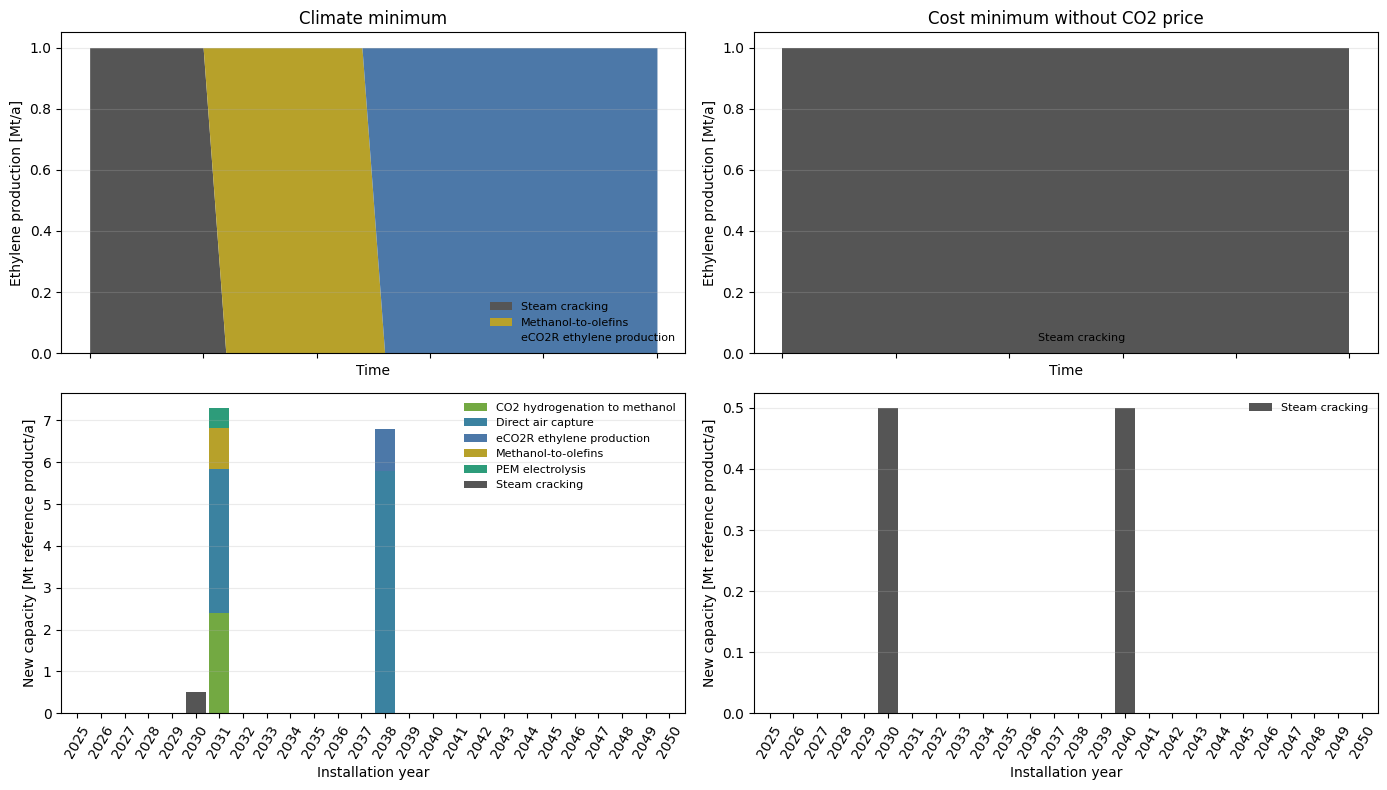

In [21]:
plot_colors = {
    "steam_cracking": "#555555",
    "dac": "#3B82A0",
    "pem": "#2D9C7A",
    "co2_hydrogenation": "#73A942",
    "mto": "#B7A12A",
    "eco2r": "#4C78A8",
}


def scenario_tables(model):
    processor = postprocessing.PostProcessor(model)
    production = processor.get_production()
    ethylene_columns = [
        column for column in production.columns if column[1] == "ethylene"
    ]
    route_production = production[ethylene_columns].copy() / 1e9
    route_production.columns = [column[0] for column in ethylene_columns]
    route_production = route_production.mask(
        route_production.abs() < 1e-9, 0.0
    ).clip(lower=0.0)
    route_production = route_production.loc[
        :, (route_production.abs() > 1e-9).any(axis=0)
    ]

    installation = processor.get_installation().copy()
    for process_code in installation.columns:
        installation[process_code] /= LIFETIMES_YEARS[process_code]
    installation /= 1e9
    installation = installation.mask(
        installation.abs() < 1e-9, 0.0
    ).clip(lower=0.0)
    installation = installation.loc[
        :, (installation.abs() > 1e-9).any(axis=0)
    ]
    return route_production, installation


scenario_models = {
    "Climate minimum": climate_model,
    "Cost minimum without CO2 price": cost_model,
}
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

for column_index, (title, model) in enumerate(scenario_models.items()):
    production, installation = scenario_tables(model)
    production.rename(columns=PROCESS_NAMES).plot.area(
        ax=axes[0, column_index],
        stacked=True,
        color=[plot_colors[key] for key in production.columns],
        linewidth=0,
    )
    axes[0, column_index].set_title(title)
    axes[0, column_index].set_ylabel("Ethylene production [Mt/a]")
    axes[0, column_index].set_ylim(bottom=0)
    axes[0, column_index].tick_params(axis="x", labelbottom=False)

    installation.rename(columns=PROCESS_NAMES).plot.bar(
        ax=axes[1, column_index],
        stacked=True,
        color=[plot_colors[key] for key in installation.columns],
        width=0.85,
    )
    axes[1, column_index].set_ylabel("New capacity [Mt reference product/a]")
    axes[1, column_index].set_xlabel("Installation year")
    axes[1, column_index].tick_params(axis="x", rotation=60)

for axis in axes.flat:
    axis.grid(axis="y", alpha=0.25)
    axis.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

### Climate minimum: capacity balance

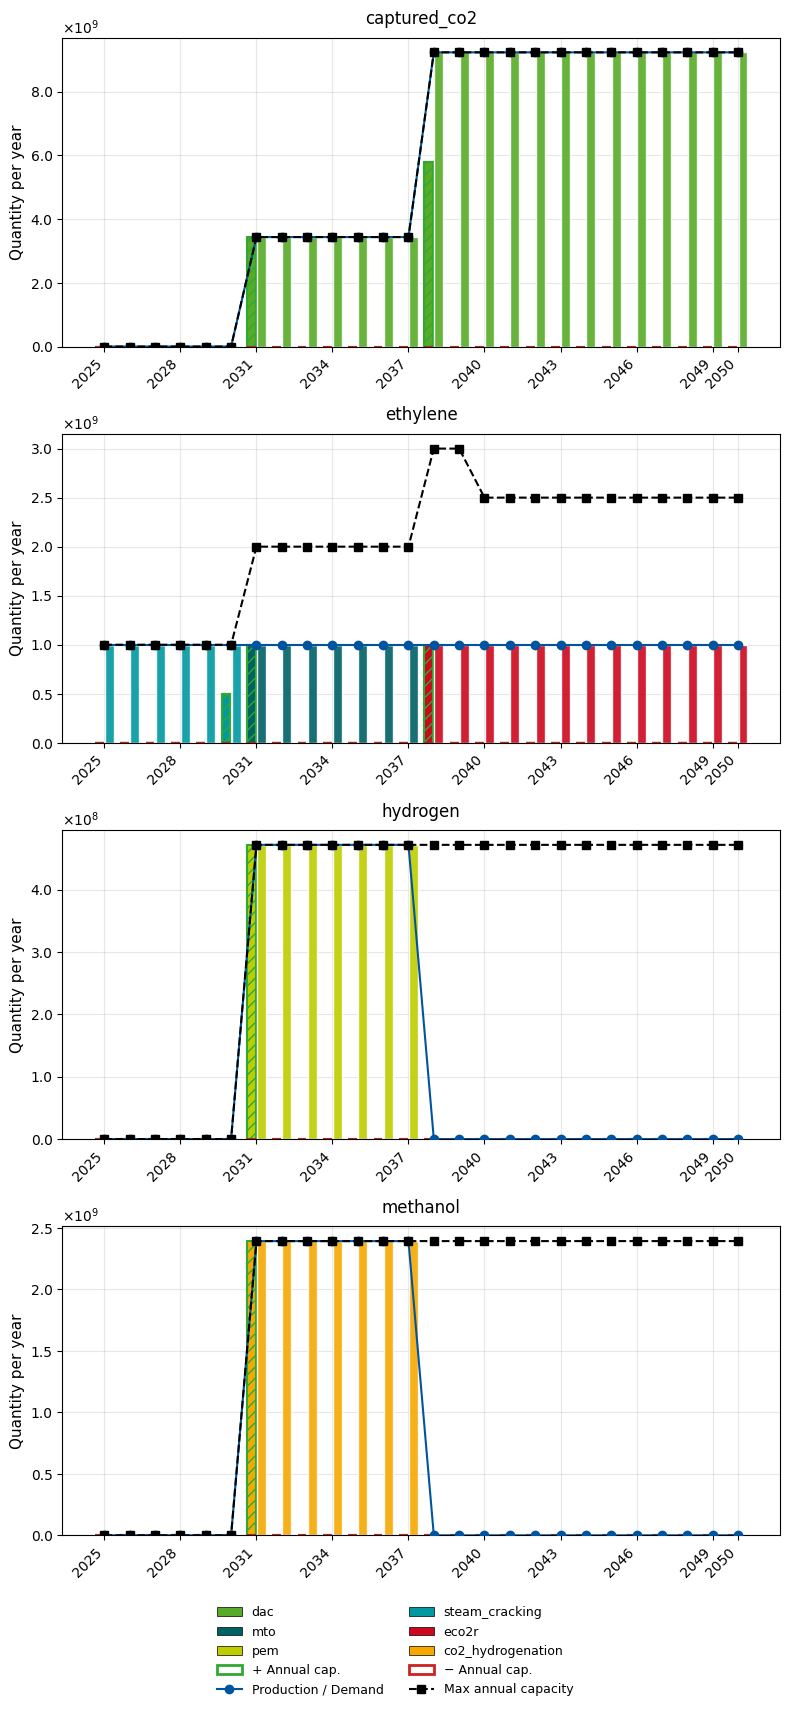

### Climate minimum: environmental impacts

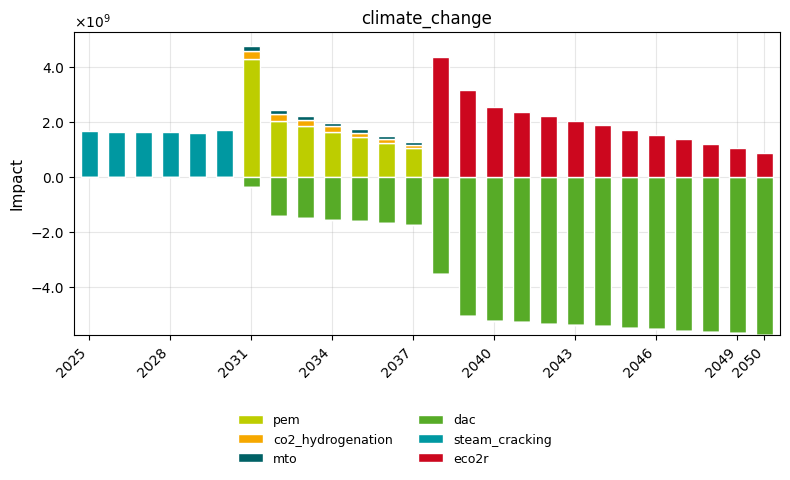

### Cost minimum without CO2 price: capacity balance

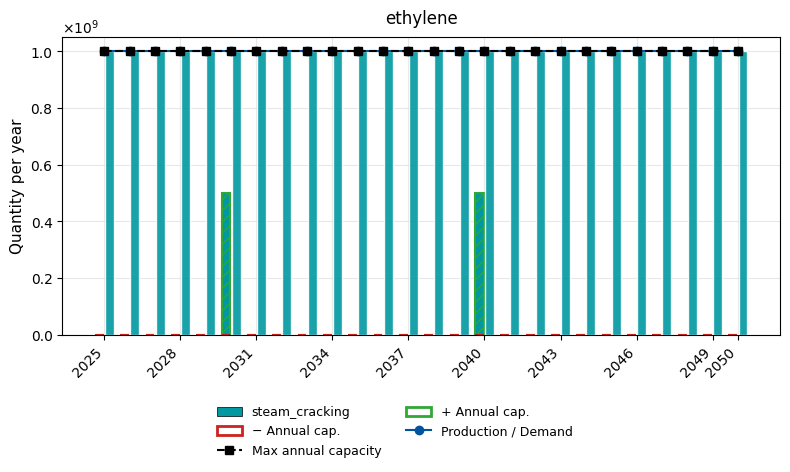

### Cost minimum without CO2 price: environmental impacts

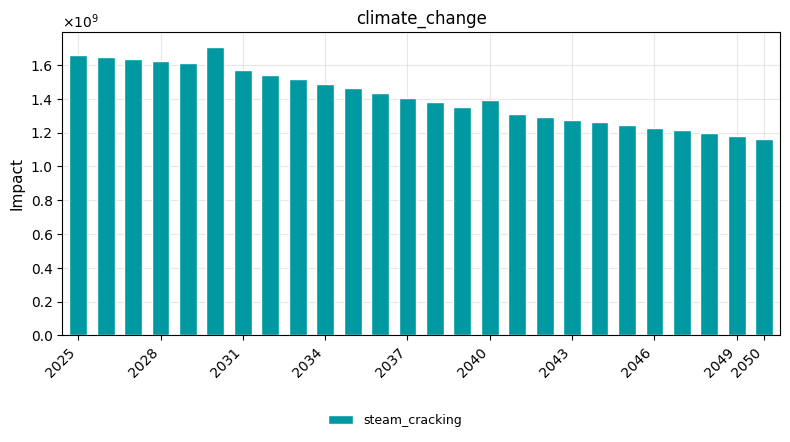

In [22]:
from IPython.display import Markdown, display


result_processors = {
    "Climate minimum": postprocessing.PostProcessor(
        climate_model,
        plot_config={"figsize": (8, 4)},
    ),
    "Cost minimum without CO2 price": postprocessing.PostProcessor(
        cost_model,
        plot_config={"figsize": (8, 4)},
    ),
}

for scenario_name, processor in result_processors.items():
    display(Markdown(f"### {scenario_name}: capacity balance"))
    processor.plot_capacity_balance(detailed=True)

    display(Markdown(f"### {scenario_name}: environmental impacts"))
    processor.plot_impacts()

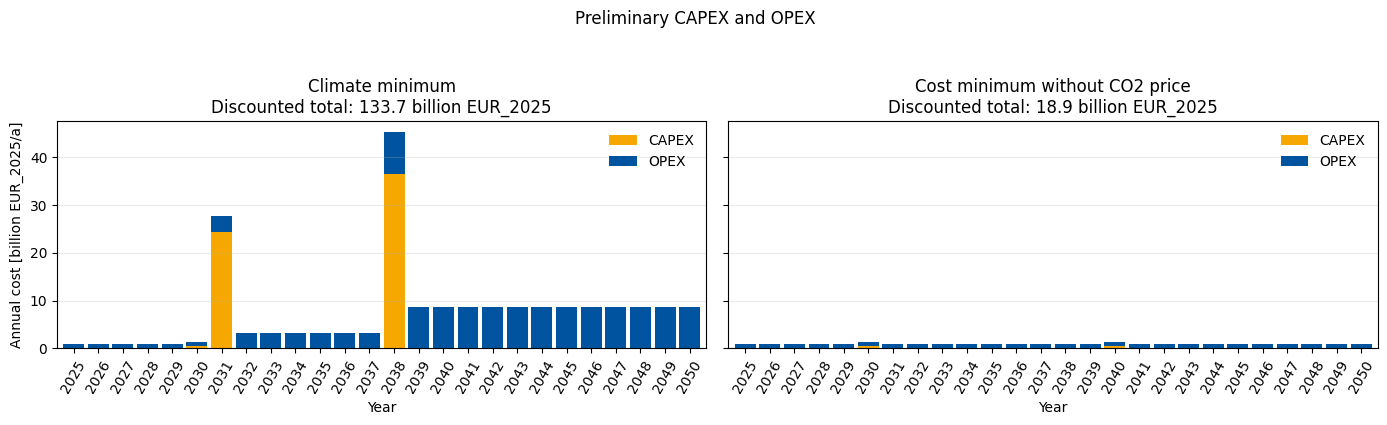

In [23]:
def annual_cost_table(model):
    years = list(model.SYSTEM_TIME)
    costs = pd.DataFrame(
        {
            "CAPEX": [pyo.value(model.cost_cap[year]) for year in years],
            "OPEX": [pyo.value(model.cost_op[year]) for year in years],
        },
        index=years,
    )
    costs.index.name = "Year"
    return costs / 1e9


cost_scenario_models = {
    "Climate minimum": climate_model,
    "Cost minimum without CO2 price": cost_model,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
cost_plot_colors = {"CAPEX": "#F6A800", "OPEX": "#00549F"}

for axis, (scenario_name, model) in zip(axes, cost_scenario_models.items()):
    annual_costs = annual_cost_table(model)
    annual_costs.plot.bar(
        ax=axis,
        stacked=True,
        color=[cost_plot_colors[column] for column in annual_costs.columns],
        width=0.85,
    )
    discounted_total = pyo.value(model.total_cost) / 1e9
    axis.set_title(
        f"{scenario_name}\nDiscounted total: {discounted_total:,.1f} billion EUR_2025"
    )
    axis.set_xlabel("Year")
    axis.set_ylabel("Annual cost [billion EUR_2025/a]")
    axis.tick_params(axis="x", rotation=60)
    axis.grid(axis="y", alpha=0.25)
    axis.legend(frameon=False)

fig.suptitle("Preliminary CAPEX and OPEX", y=1.05)
plt.tight_layout()
plt.show()

## 10. Climate-budget sweep

The two extreme solutions define the range of feasible cumulative climate
impacts. Intermediate scenarios minimize discounted total cost subject to
progressively stricter cumulative climate budgets. Climate ambition is
normalized from 0% (the unconstrained cost minimum) to 100% (the climate
minimum). The independently calculated extrema are retained as endpoints;
the intermediate points are cost minima under cumulative climate constraints.
All other model inputs remain unchanged.


In [24]:
COST_MINIMUM_IMPACT = cumulative_climate_impact(cost_model)
CLIMATE_MINIMUM_IMPACT = cumulative_climate_impact(climate_model)
CLIMATE_AMBITION = np.linspace(0.0, 1.0, 17)
SELECTED_AMBITION = {0.0, 0.25, 0.5, 0.75, 1.0}


def cost_minimum_with_climate_budget(climate_budget, scenario_number):
    constrained_data = scenario_inputs.model_dump()
    constrained_data["cumulative_category_impact_limits"] = {
        "climate_change": float(climate_budget)
    }
    constrained_inputs = converter.OptimizationModelInputs(**constrained_data)
    model = optimizer.create_model(
        constrained_inputs,
        name=f"ethylene_climate_budget_{scenario_number:02d}",
        objective_category="climate_change",
        objective="cost",
    )
    return optimizer.solve_model(model, solver_name=SOLVER, tee=False)


sweep_rows = []
selected_sweep_models = {0.0: cost_model}
for scenario_number, ambition in enumerate(CLIMATE_AMBITION):
    climate_budget = COST_MINIMUM_IMPACT - ambition * (
        COST_MINIMUM_IMPACT - CLIMATE_MINIMUM_IMPACT
    )
    if np.isclose(ambition, 0.0):
        model = cost_model
        discounted_cost = cost_objective
    elif np.isclose(ambition, 1.0):
        model = climate_model
        discounted_cost = pyo.value(climate_model.total_cost)
    else:
        model, discounted_cost, _ = cost_minimum_with_climate_budget(
            climate_budget, scenario_number
        )

    production, _ = scenario_tables(model)
    route_output = production.reindex(columns=plot_colors, fill_value=0.0).sum()
    total_output = route_output.sum()
    row = {
        "climate_ambition": float(ambition),
        "climate_budget_kg_CO2eq": float(climate_budget),
        "cumulative_climate_kg_CO2eq": cumulative_climate_impact(model),
        "discounted_cost_EUR_2025": float(discounted_cost),
    }
    for route in ("steam_cracking", "mto", "eco2r"):
        row[f"share_{route}"] = float(route_output[route] / total_output)
    sweep_rows.append(row)

    if any(np.isclose(ambition, selected) for selected in SELECTED_AMBITION):
        selected_sweep_models[float(ambition)] = model

sweep_results = pd.DataFrame(sweep_rows)
sweep_results.assign(
    climate_ambition_percent=100 * sweep_results["climate_ambition"],
    climate_budget_Mt_CO2eq=sweep_results["climate_budget_kg_CO2eq"] / 1e9,
    cumulative_climate_Mt_CO2eq=(
        sweep_results["cumulative_climate_kg_CO2eq"] / 1e9
    ),
    discounted_cost_billion_EUR_2025=(
        sweep_results["discounted_cost_EUR_2025"] / 1e9
    ),
)[
    [
        "climate_ambition_percent",
        "climate_budget_Mt_CO2eq",
        "cumulative_climate_Mt_CO2eq",
        "discounted_cost_billion_EUR_2025",
        "share_steam_cracking",
        "share_mto",
        "share_eco2r",
    ]
]


2026-09-10 14:24:41.108 | INFO     | optimex.optimizer:create_model:148 - Creating sets


2026-09-10 14:24:41.111 | INFO     | optimex.optimizer:create_model:188 - Creating parameters


2026-09-10 14:24:41.422 | INFO     | optimex.optimizer:create_model:613 - Creating variables


2026-09-10 14:24:43.254 | INFO     | optimex.optimizer:solve_model:1362 - Solver [highs] termination: optimal


2026-09-10 14:24:43.289 | INFO     | optimex.optimizer:solve_model:1368 - Objective (cost): 2.2708e+10


...

2026-09-10 14:25:30.804 | INFO     | optimex.optimizer:create_model:188 - Creating parameters


2026-09-10 14:25:31.127 | INFO     | optimex.optimizer:create_model:613 - Creating variables


2026-09-10 14:25:32.153 | INFO     | optimex.optimizer:solve_model:1362 - Solver [highs] termination: optimal


2026-09-10 14:25:32.185 | INFO     | optimex.optimizer:solve_model:1368 - Objective (cost): 1.11509e+11


,climate_ambition_percent,climate_budget_Mt_CO2eq,cumulative_climate_Mt_CO2eq,discounted_cost_billion_EUR_2025,share_steam_cracking,share_mto,share_eco2r
0,0.00,36.820119,36.820119,18.852767,1.000000,0.000000,0.000000
1,6.25,32.852672,32.852672,22.708031,0.942542,0.057458,0.000000
2,12.50,28.885225,28.885225,26.563294,0.885085,0.114915,0.000000
3,18.75,24.917778,24.917778,30.418558,0.827627,0.172373,0.000000
4,25.00,20.950330,20.950330,34.273821,0.770170,0.229830,0.000000
5,31.25,16.982883,16.982883,38.205808,0.712468,0.287532,0.000000
6,37.50,13.015436,13.015436,42.139069,0.654762,0.345238,0.000000
7,43.75,9.047989,9.047989,46.072330,0.597056,0.402944,0.000000
8,50.00,5.080541,5.080541,50.005591,0.539350,0.460650,0.000000
9,56.25,1.113094,1.113094,54.434075,0.456833,0.543167,0.000000


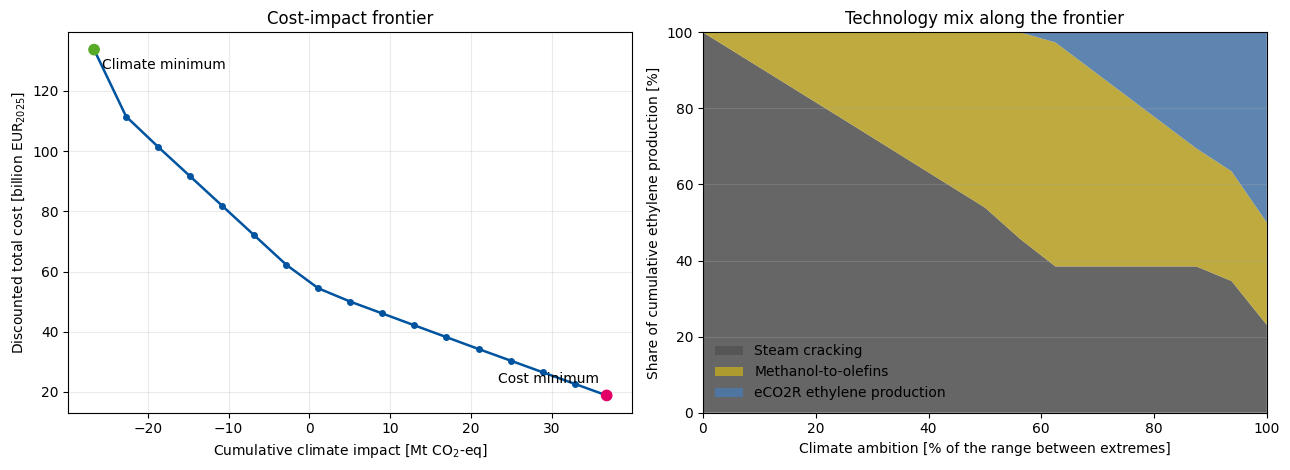

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

curve = sweep_results.sort_values("cumulative_climate_kg_CO2eq")
axes[0].plot(
    curve["cumulative_climate_kg_CO2eq"] / 1e9,
    curve["discounted_cost_EUR_2025"] / 1e9,
    color="#00549F",
    marker="o",
    markersize=4,
    linewidth=1.8,
)
axes[0].scatter(
    [CLIMATE_MINIMUM_IMPACT / 1e9, COST_MINIMUM_IMPACT / 1e9],
    [
        sweep_results.iloc[-1]["discounted_cost_EUR_2025"] / 1e9,
        cost_objective / 1e9,
    ],
    color=["#57AB27", "#E30066"],
    s=55,
    zorder=3,
)
axes[0].annotate("Climate minimum", (CLIMATE_MINIMUM_IMPACT / 1e9, sweep_results.iloc[-1]["discounted_cost_EUR_2025"] / 1e9), xytext=(6, -14), textcoords="offset points")
axes[0].annotate("Cost minimum", (COST_MINIMUM_IMPACT / 1e9, cost_objective / 1e9), xytext=(-78, 9), textcoords="offset points")
axes[0].set_xlabel("Cumulative climate impact [Mt CO$_2$-eq]")
axes[0].set_ylabel("Discounted total cost [billion EUR$_{2025}$]")
axes[0].set_title("Cost-impact frontier")
axes[0].grid(alpha=0.25)

ambition_percent = 100 * sweep_results["climate_ambition"]
route_share_columns = ["share_steam_cracking", "share_mto", "share_eco2r"]
axes[1].stackplot(
    ambition_percent,
    *[100 * sweep_results[column] for column in route_share_columns],
    labels=[PROCESS_NAMES[route] for route in ("steam_cracking", "mto", "eco2r")],
    colors=[plot_colors[route] for route in ("steam_cracking", "mto", "eco2r")],
    alpha=0.9,
)
axes[1].set_xlabel("Climate ambition [% of the range between extremes]")
axes[1].set_ylabel("Share of cumulative ethylene production [%]")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].set_title("Technology mix along the frontier")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False, loc="lower left")

plt.tight_layout()
plt.show()


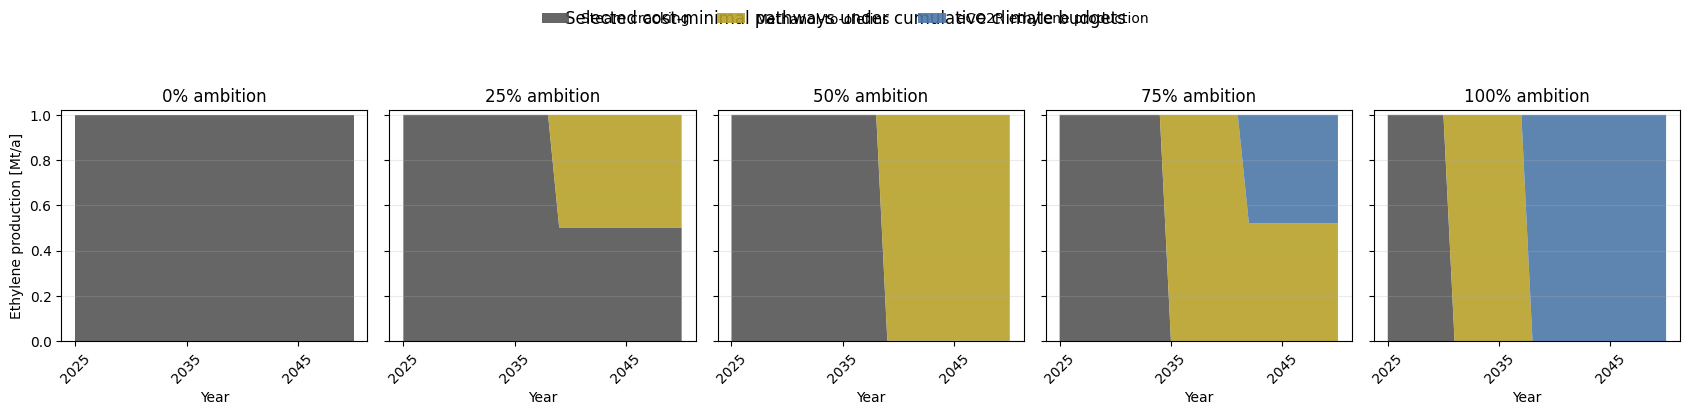

In [26]:
selected_ambition = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8), sharex=True, sharey=True)
route_order = ("steam_cracking", "mto", "eco2r")

for axis, ambition in zip(axes, selected_ambition):
    production, _ = scenario_tables(selected_sweep_models[ambition])
    production = production.reindex(columns=route_order, fill_value=0.0)
    axis.stackplot(
        production.index,
        *[production[route] for route in route_order],
        labels=[PROCESS_NAMES[route] for route in route_order],
        colors=[plot_colors[route] for route in route_order],
        alpha=0.9,
    )
    axis.set_title(f"{ambition:.0%} ambition")
    axis.set_xlabel("Year")
    axis.set_ylim(0, 1.02)
    axis.set_xticks([2025, 2035, 2045])
    axis.tick_params(axis="x", rotation=45)
    axis.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Ethylene production [Mt/a]")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Selected cost-minimal pathways under cumulative climate budgets", y=1.08)
plt.tight_layout()
plt.show()


## 11. Interpretation boundary

All assumptions marked `replacement_needed=True` and all `PROXY` or
`PLACEHOLDER` prices must be reviewed before the results are used in the
Bachelor thesis. Steam, PEM, MTO, CO2-hydrogenation and eCO2R installation prices
are normalized to capacity-based reference wrappers. Their internal exchanges
preserve the original environmental installation coefficients. Steam and eCO2R
CAPEX remain explicit proxies, and several future price trajectories remain proxy assumptions.
The eCO2R result excludes separated co-products: neither their purification
burdens nor potential product credits are included.

The climate-budget sweep varies only the cumulative climate constraint. CO2
pricing and vintage improvements are not part of this baseline.